#### Importing libraries

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

#### Reading the dataset

In [2]:
df=pd.read_csv('personal_transactions.csv')
df

,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card
...,...,...,...,...,...,...
801,09/27/2019,Biweekly Paycheck,2250.00,credit,Paycheck,Checking
802,09/28/2019,BP,33.46,debit,Gas & Fuel,Platinum Card
803,09/28/2019,Sheetz,4.27,debit,Gas & Fuel,Platinum Card
804,09/30/2019,Starbucks,1.75,debit,Coffee Shops,Platinum Card


#### Analyzing the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              806 non-null    object 
 1   Description       806 non-null    object 
 2   Amount            806 non-null    float64
 3   Transaction Type  806 non-null    object 
 4   Category          806 non-null    object 
 5   Account Name      806 non-null    object 
dtypes: float64(1), object(5)
memory usage: 37.9+ KB


In [4]:
df.describe()

,Amount
count,806.000000
mean,273.391489
std,667.630374
min,1.750000
25%,15.687500
50%,37.480000
75%,117.680000
max,9200.000000


In [5]:
df.corr()

,Amount
Amount,1.0


#### Check null values

In [6]:
df.isnull().sum()

Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
dtype: int64

#### Change datatype of date

In [7]:
df['Date']=pd.to_datetime(df['Date'])

In [8]:
df.dtypes

Date                datetime64[ns]
Description                 object
Amount                     float64
Transaction Type            object
Category                    object
Account Name                object
dtype: object

#### Check duplicate values

In [9]:
df.duplicated().sum()

0

#### Check unique values

In [10]:
df['Category'].unique()

array(['Shopping', 'Mortgage & Rent', 'Restaurants',
       'Credit Card Payment', 'Movies & DVDs', 'Home Improvement',
       'Utilities', 'Music', 'Mobile Phone', 'Gas & Fuel', 'Groceries',
       'Paycheck', 'Fast Food', 'Coffee Shops', 'Internet', 'Haircut',
       'Alcohol & Bars', 'Auto Insurance', 'Entertainment',
       'Food & Dining', 'Television', 'Electronics & Software'],
      dtype=object)

In [11]:
df['Transaction Type'].unique()

array(['debit', 'credit'], dtype=object)

#### Check Outliers

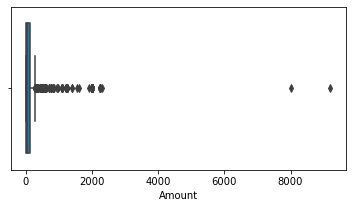

In [12]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df['Amount'])

plt.show()

In [13]:
df.dropna(inplace=True)
df

,Date,Description,Amount,Transaction Type,Category,Account Name
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card
...,...,...,...,...,...,...
801,2019-09-27,Biweekly Paycheck,2250.00,credit,Paycheck,Checking
802,2019-09-28,BP,33.46,debit,Gas & Fuel,Platinum Card
803,2019-09-28,Sheetz,4.27,debit,Gas & Fuel,Platinum Card
804,2019-09-30,Starbucks,1.75,debit,Coffee Shops,Platinum Card


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 806 entries, 0 to 805
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              806 non-null    datetime64[ns]
 1   Description       806 non-null    object        
 2   Amount            806 non-null    float64       
 3   Transaction Type  806 non-null    object        
 4   Category          806 non-null    object        
 5   Account Name      806 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 44.1+ KB


#### Feature Engineering

In [15]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Create separate encoders
category_encoder = LabelEncoder()
transaction_encoder = LabelEncoder()
account_encoder = LabelEncoder()

# Fit and transform
df["Category"] = category_encoder.fit_transform(df["Category"])

df["Transaction Type"] = transaction_encoder.fit_transform(df["Transaction Type"])

df["Account Name"] = account_encoder.fit_transform(df["Account Name"])

# Save encoders
joblib.dump(category_encoder, "category_encoder.pkl")
joblib.dump(transaction_encoder, "transaction_encoder.pkl")
joblib.dump(account_encoder, "account_encoder.pkl")

['account_encoder.pkl']

In [16]:
df.drop("Description", axis=1, inplace=True)

In [17]:
df.drop("Date", axis=1, inplace=True)

#### Select feature

In [18]:
x = df.drop("Transaction Type", axis=1)

y = df["Transaction Type"]

#### Train-Test Split 

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### Trained multiple models

#### 1. Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train, y_train)

LogisticRegression()

#### 2. Decsion Tree Classifier

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(x_train, y_train)

DecisionTreeClassifier()

#### 3. Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42,class_weight='balanced')

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

#### 4. KNN

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(x_train, y_train)

KNeighborsClassifier()

#### 5. Navie Bays

In [24]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train, y_train)

GaussianNB()

#### 6. XGBoost

In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

xgb.fit(x_train, y_train)

pred = xgb.predict(x_test)

#### Make predictions

In [26]:
pred = xgb.predict(x_test)

### Evaluate the models

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(accuracy_score(y_test,pred))

print(confusion_matrix(y_test,pred))

print(classification_report(y_test,pred))

0.9938271604938271
[[ 18   1]
 [  0 143]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.99      1.00      1.00       143

    accuracy                           0.99       162
   macro avg       1.00      0.97      0.98       162
weighted avg       0.99      0.99      0.99       162



#### Compare all models

In [28]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier()
}

results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, pred)
    results.append([name, acc])


result_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(result_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
1        Decision Tree  1.000000
2        Random Forest  1.000000
5              XGBoost  0.993827
0  Logistic Regression  0.950617
4          Naive Bayes  0.925926
3                  KNN  0.901235


#### Visual Model Accuracy

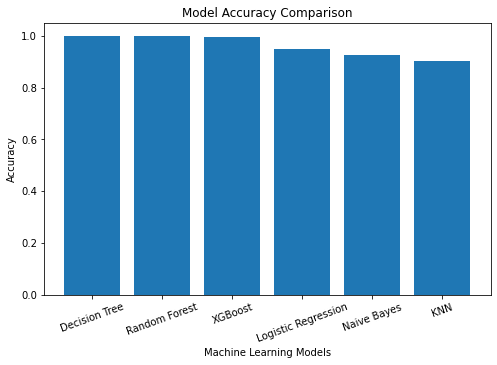

In [29]:

result_df = result_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(result_df["Model"], result_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

#### Save the best model

In [30]:
import joblib

joblib.dump(xgb,"personal_transactions.pkl")

['personal_transactions.pkl']

### Build a Dashboard